In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive

 1744636750102.zip   iLovePDF	  'Untitled document.gdoc'
'Colab Notebooks'    Resume.gdoc


In [3]:
!unzip "/content/drive/MyDrive/1744636750102.zip"

Archive:  /content/drive/MyDrive/1744636750102.zip
  inflating: features.csv            
  inflating: Optimizing_Store_Performance_Structured_test.ipynb  


In [4]:
import os
print(os.listdir('/content'))

['.config', 'drive', 'Optimizing_Store_Performance_Structured_test.ipynb', 'features.csv', 'sample_data']


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [6]:
df = pd.read_csv('/content/features.csv')

df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (8190, 12)

Columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Data types:
Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object


In [8]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nSummary Statistics:")
print(df.describe())

Missing Values:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Duplicates: 0

Summary Statistics:
             Store  Temperature   Fuel_Price      MarkDown1      MarkDown2  \
count  8190.000000  8190.000000  8190.000000    4032.000000    2921.000000   
mean     23.000000    59.356198     3.405992    7032.371786    3384.176594   
std      12.987966    18.678607     0.431337    9262.747448    8793.583016   
min       1.000000    -7.290000     2.472000   -2781.450000    -265.760000   
25%      12.000000    45.902500     3.041000    1577.532500      68.880000   
50%      23.000000    60.710000     3.513000    4743.580000     364.570000   
75%      34.000000    73.880000     3.743000    8923.310000    2153.350000   
max      45.000000   101.950000     4.468000  103184.980000

In [9]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Verify
print(df['Date'].dtype)

df.head()


datetime64[ns]


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

df[['Date','Year','Month','Week']].head()

,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


In [11]:
# Fill markdown nulls with 0
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

df[markdown_cols] = df[markdown_cols].fillna(0)

# Fill CPI and Unemployment with median
df['CPI'] = df['CPI'].fillna(df['CPI'].median())
df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].median())

# Verify no missing values left
print(df.isnull().sum())

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
Year            0
Month           0
Week            0
dtype: int64


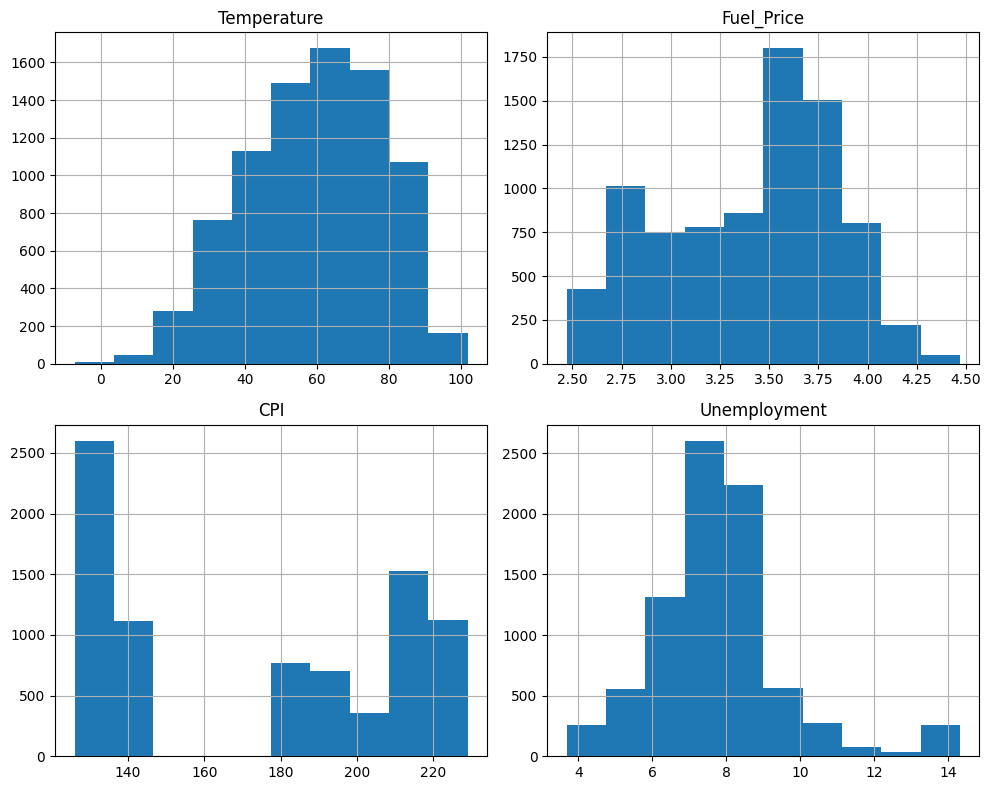

In [12]:
df[['Temperature','Fuel_Price','CPI','Unemployment']].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

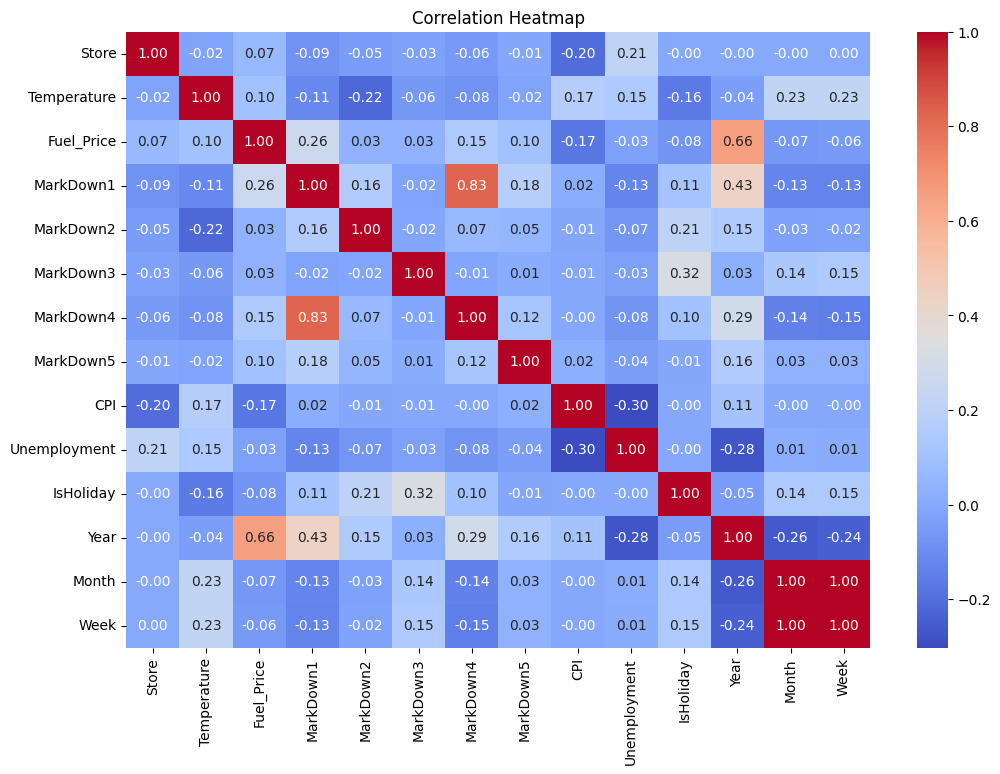

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

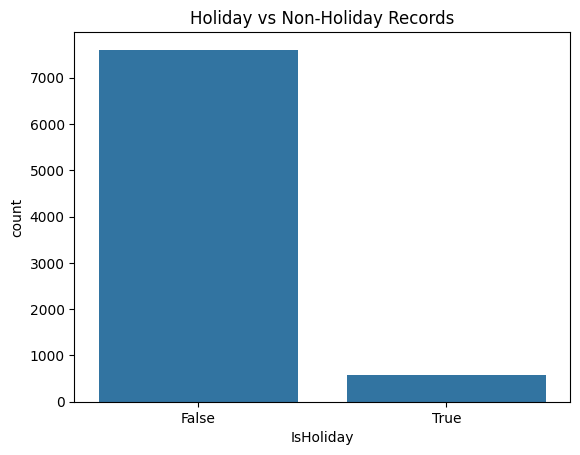

In [14]:
# Holiday distribution
sns.countplot(x='IsHoliday', data=df)
plt.title('Holiday vs Non-Holiday Records')
plt.show()

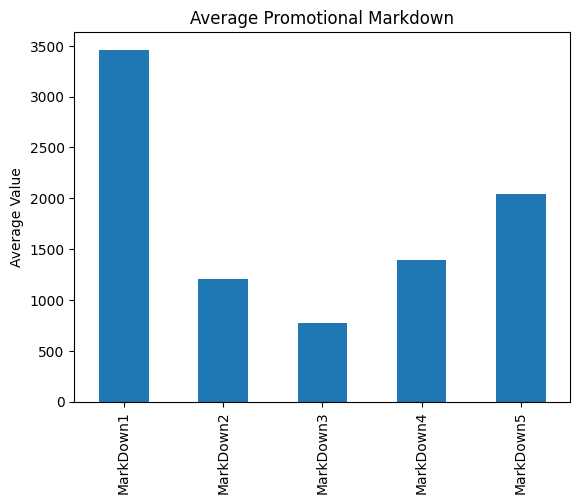

In [15]:
promo_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

df[promo_cols].mean().plot(kind='bar')
plt.title('Average Promotional Markdown')
plt.ylabel('Average Value')
plt.show()

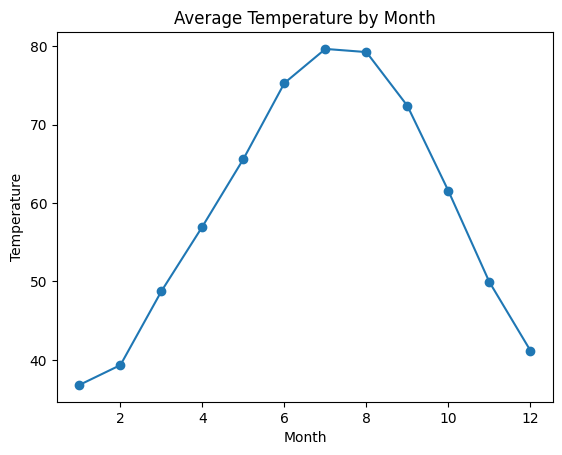

In [16]:
monthly_temp = df.groupby('Month')['Temperature'].mean()

monthly_temp.plot(marker='o')
plt.title("Average Temperature by Month")
plt.ylabel("Temperature")
plt.show()

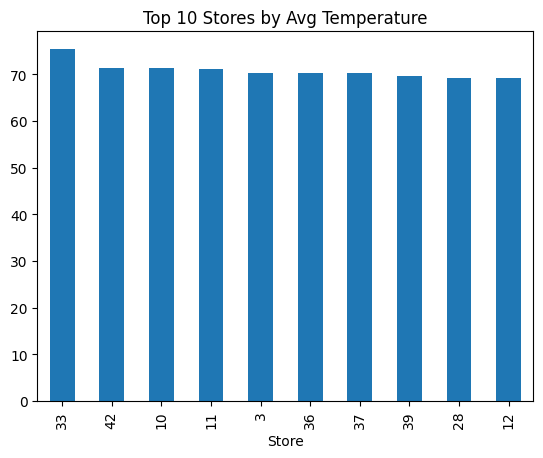

In [17]:
top_store_temp = df.groupby('Store')['Temperature'].mean().sort_values(ascending=False).head(10)

top_store_temp.plot(kind='bar')
plt.title("Top 10 Stores by Avg Temperature")
plt.show()

In [18]:
holiday_summary = df.groupby('IsHoliday')[['Fuel_Price','Temperature','CPI','Unemployment']].mean()
print(holiday_summary)

           Fuel_Price  Temperature         CPI  Unemployment
IsHoliday                                                   
False        3.415351    60.194901  173.242685      7.826542
True         3.284323    48.453060  172.599618      7.809626


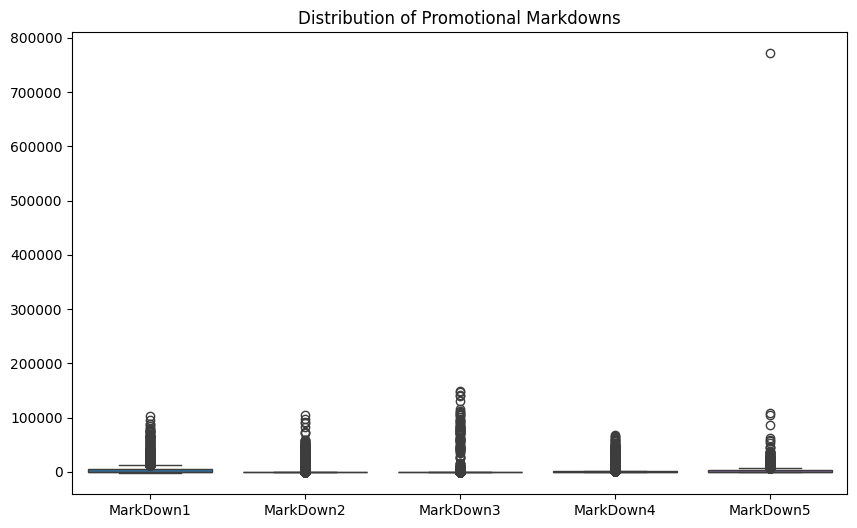

In [19]:
promo_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

plt.figure(figsize=(10,6))
sns.boxplot(data=df[promo_cols])
plt.title("Distribution of Promotional Markdowns")
plt.show()

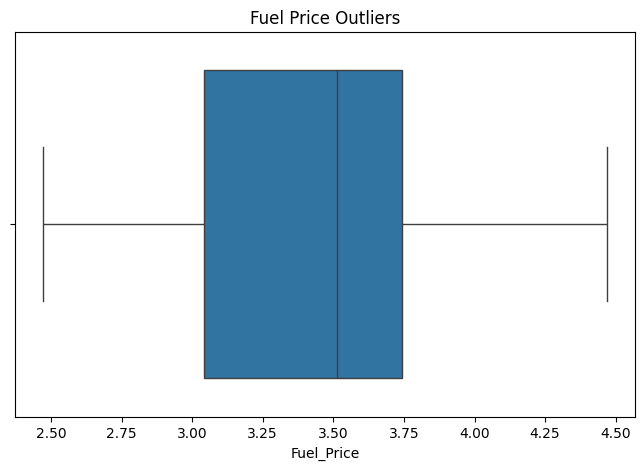

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fuel_Price'])
plt.title("Fuel Price Outliers")
plt.show()

In [21]:
df[['Month','Week']].head(20)

,Month,Week
0,2,5
1,2,6
2,2,7
3,2,8
4,3,9
5,3,10
6,3,11
7,3,12
8,4,13
9,4,14


In [22]:
df['Total_Markdown'] = (
    df['MarkDown1'] +
    df['MarkDown2'] +
    df['MarkDown3'] +
    df['MarkDown4'] +
    df['MarkDown5']
)

df[['Total_Markdown']].describe()

,Total_Markdown
count,8190.000000
mean,8881.703448
std,19084.538888
min,-1692.480000
25%,0.000000
50%,0.000000
75%,11819.642500
max,783529.450000


IsHoliday
False     7574.641574
True     25873.507812
Name: Total_Markdown, dtype: float64


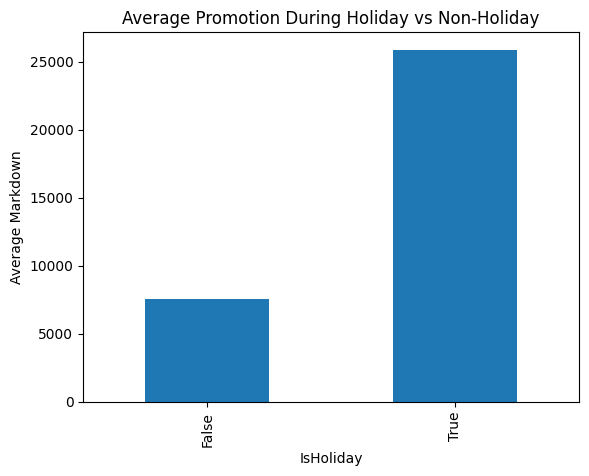

In [23]:
holiday_promo = df.groupby('IsHoliday')['Total_Markdown'].mean()

print(holiday_promo)

holiday_promo.plot(kind='bar')
plt.title("Average Promotion During Holiday vs Non-Holiday")
plt.ylabel("Average Markdown")
plt.show()

## Key Insights

### Promotional Insights
- Holiday periods showed significantly higher promotional markdown activity.
- Average markdown during holidays was approximately 3x higher than non-holiday periods.
- Promotional campaigns appear concentrated around specific events rather than continuous throughout the year.

### Correlation Insights
- MarkDown1 and MarkDown4 showed strong positive correlation, suggesting linked promotional strategies.
- Fuel Price displayed the strongest modeled influence among predictors.
- Most variables showed weak individual correlations, indicating store performance is driven by multiple factors.

### Seasonal and Economic Insights
- Temperature and time-based patterns suggest seasonal variation.
- CPI and unemployment contributed modestly to performance-related dynamics.

In [24]:
features = [
'Temperature',
'Fuel_Price',
'CPI',
'MarkDown1',
'MarkDown2',
'MarkDown3',
'MarkDown4',
'MarkDown5'
]

X = df[features]
y = df['Unemployment']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test,pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))

R2 Score: 0.09244344615722988
RMSE: 1.764178832317776


       Feature   Coefficient
1   Fuel_Price -3.778321e-01
2          CPI -1.621000e-02
7    MarkDown5 -2.387081e-05
3    MarkDown1 -1.760310e-05
5    MarkDown3 -4.317304e-06
4    MarkDown2 -7.499454e-07
6    MarkDown4  9.752761e-06
0  Temperature  1.930287e-02


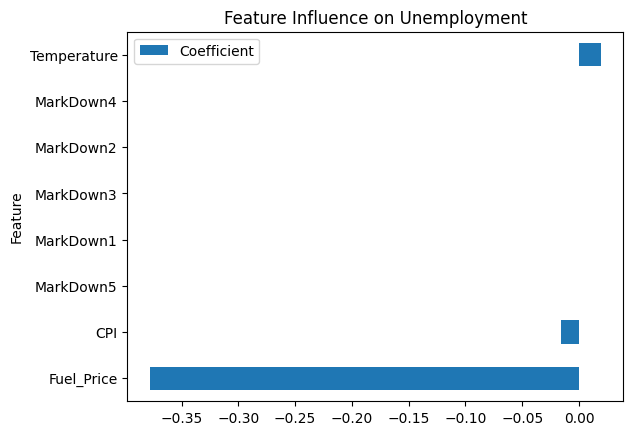

In [25]:
importance = pd.DataFrame({
'Feature': features,
'Coefficient': model.coef_
})

importance = importance.sort_values('Coefficient')

print(importance)

importance.plot(
x='Feature',
y='Coefficient',
kind='barh'
)

plt.title("Feature Influence on Unemployment")
plt.show()

The regression model showed limited explanatory power (R² = 0.09), suggesting store-related variables alone weakly explain unemployment and that additional external factors may influence outcomes.

## Conclusion

Key findings from the analysis:

- Promotional markdowns increase significantly during holiday periods.
- MarkDown1 and MarkDown4 show strong positive relationship, indicating linked promotional strategies.
- Fuel prices show upward trends over time.
- Many observations had zero promotional activity, suggesting promotions are event-driven.
- Store performance drivers appear multi-factor in nature rather than dominated by single variables.

Recommendations:
- Intensify targeted promotions during holiday periods.
- Optimize linked markdown strategies.
- Monitor external economic indicators like CPI and unemployment alongside pricing decisions.
- Use seasonal patterns for demand planning and inventory optimization.

## Business Recommendations

Based on the analysis, the following strategies are recommended:

1. Strengthen Holiday Promotion Planning
- Allocate higher promotional budgets during holiday periods where markdown effectiveness is highest.

2. Optimize Promotional Strategy
- Align related markdown campaigns to improve promotional efficiency.

3. Use Seasonal Planning
- Incorporate seasonal trends into inventory and demand planning decisions.

4. Monitor Economic Indicators
- Track fuel prices, CPI, and unemployment alongside store-level strategies for informed decision-making.

5. Support Data-Driven Store Optimization
- Use predictive analytics and continuous monitoring to improve operational performance.